Current Bandwidth: 0.0977
STATUS: Normal Volatility.


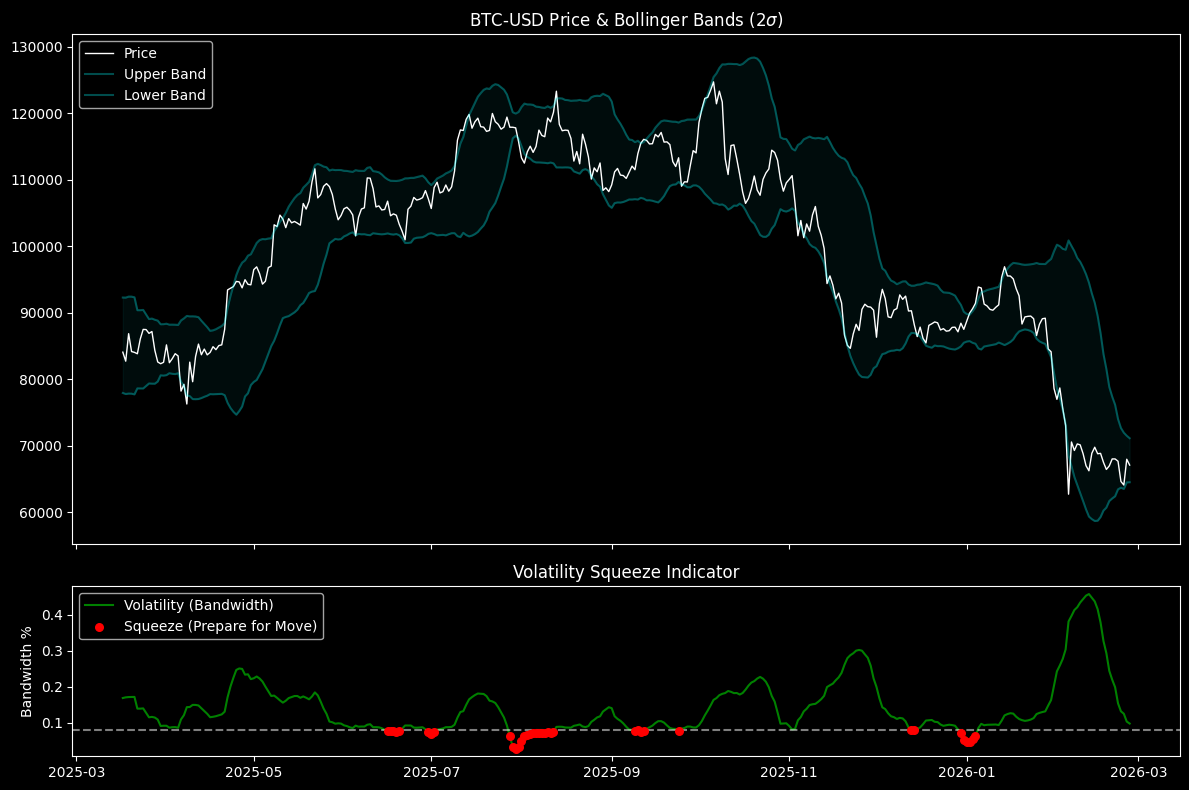

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
TICKER = 'BTC-USD'    # Crypto is great for volatility strategies
LOOKBACK = 20         # Standard Bollinger Band Window
STD_DEV = 2.0         # Standard Deviation Factor
SQUEEZE_THRESH = 0.08 # Threshold for "Low Volatility" (Band Width)

def get_data(ticker):
    df = yf.download(ticker, period="1y", interval="1d", progress=False, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
    return df

def calculate_bollinger_bands(df):
    # 1. Middle Band (Simple Moving Average)
    df['SMA'] = df['Close'].rolling(window=LOOKBACK).mean()
    
    # 2. Standard Deviation
    df['std_dev'] = df['Close'].rolling(window=LOOKBACK).std()
    
    # 3. Upper and Lower Bands
    df['Upper'] = df['SMA'] + (df['std_dev'] * STD_DEV)
    df['Lower'] = df['SMA'] - (df['std_dev'] * STD_DEV)
    
    # 4. Bandwidth % (The "Squeeze" Indicator)
    # (Upper - Lower) / SMA. Low values mean volatility is dead (storm coming).
    df['Bandwidth'] = (df['Upper'] - df['Lower']) / df['SMA']
    
    return df.dropna()

def plot_squeeze(df, ticker):
    plt.style.use('dark_background')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    # Price & Bands
    ax1.plot(df.index, df['Close'], color='white', linewidth=1, label='Price')
    ax1.plot(df.index, df['Upper'], color='cyan', alpha=0.3, label='Upper Band')
    ax1.plot(df.index, df['Lower'], color='cyan', alpha=0.3, label='Lower Band')
    ax1.fill_between(df.index, df['Upper'], df['Lower'], color='cyan', alpha=0.05)
    ax1.set_title(f'{ticker} Price & Bollinger Bands (2$\sigma$)')
    ax1.legend(loc='upper left')

    # The Squeeze Indicator
    # We color the line RED when it drops below the threshold (The Squeeze Zone)
    squeeze_condition = df['Bandwidth'] < SQUEEZE_THRESH
    
    ax2.plot(df.index, df['Bandwidth'], color='green', label='Volatility (Bandwidth)')
    ax2.scatter(df[squeeze_condition].index, df[squeeze_condition]['Bandwidth'], 
                color='red', s=30, zorder=5, label='Squeeze (Prepare for Move)')
    
    ax2.axhline(SQUEEZE_THRESH, color='white', linestyle='--', alpha=0.5)
    ax2.set_ylabel('Bandwidth %')
    ax2.set_title('Volatility Squeeze Indicator')
    ax2.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    data = get_data(TICKER)
    data = calculate_bollinger_bands(data)
    
    # Check if we are in a squeeze right now
    current_bw = data['Bandwidth'].iloc[-1]
    print(f"Current Bandwidth: {current_bw:.4f}")
    
    if current_bw < SQUEEZE_THRESH:
        print("STATUS: SQUEEZE DETECTED. Expect explosive move soon.")
    else:
        print("STATUS: Normal Volatility.")
        
    plot_squeeze(data, TICKER)

Fetching BTC-USD [4h]...

--- KALMAN STATUS (BTC-USD) ---
Current Price:   $67,076.20
Projected Bias:  -0.1070% per step
Horizon Vol:     9.92% (cumulative)

--- DYNAMIC PROBABILITY MATRIX (72 Steps) ---
LEVEL      TARGET PRICE    PROBABILITY    
----------------------------------------
+3.0σ      $83,642        0.1%
+2.0σ      $75,739        2.3%
+1.5σ      $72,073        6.7%
+1.0σ      $68,584        15.9%
+0.5σ      $65,263        69.1%
-0.5σ      $59,097        30.9%
-1.0σ      $56,236        15.9%
-1.5σ      $53,514        6.7%
-2.0σ      $50,923        2.3%
-3.0σ      $46,112        0.1%


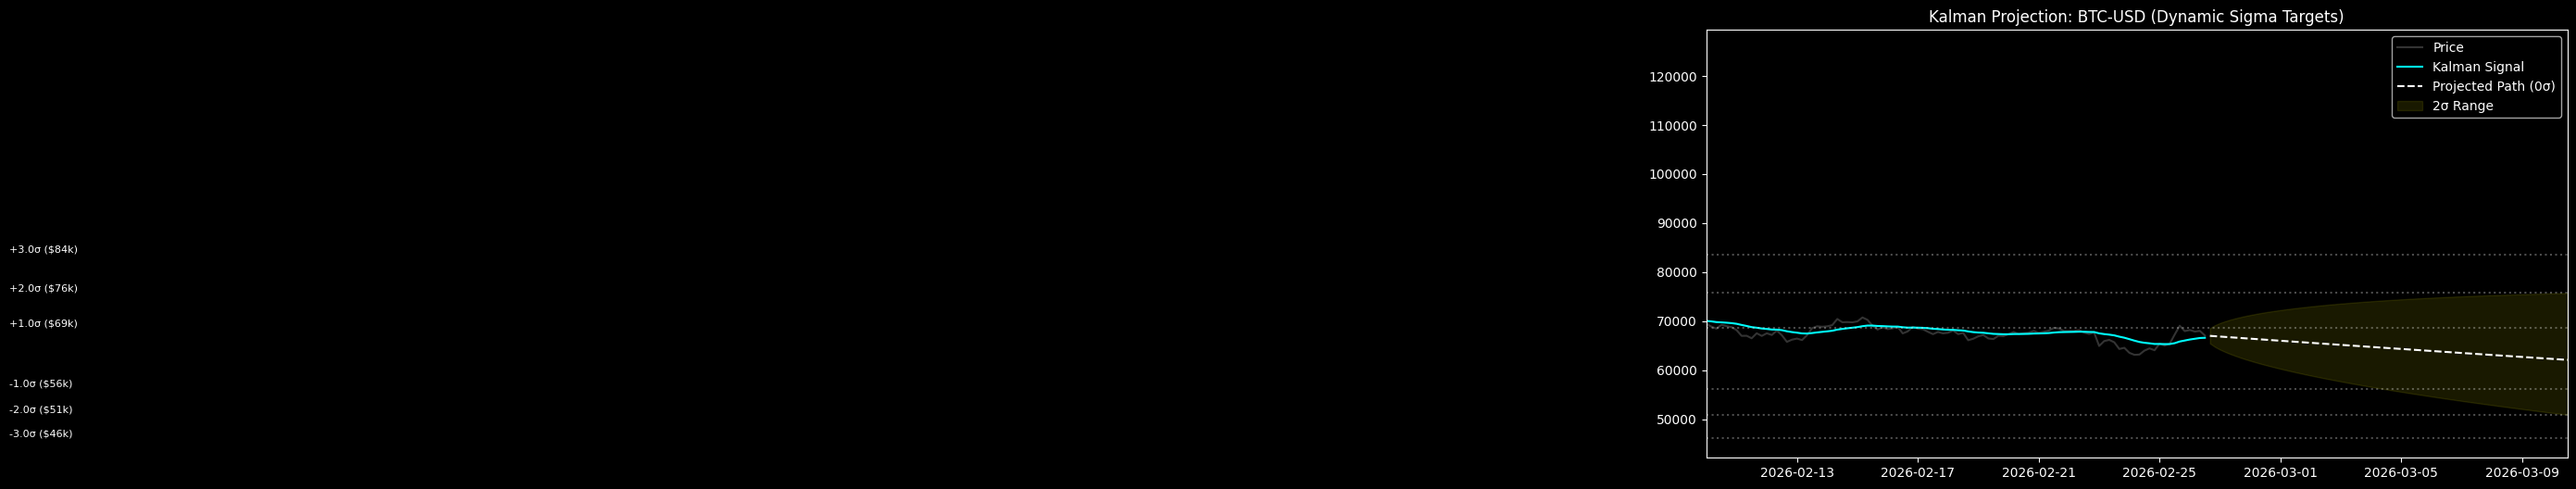

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- 1. CONFIGURATION ---
TICKER = "BTC-USD"   
INTERVAL = "4h"       
LOOKBACK = "1y"      
HORIZON_STEPS = 72    

# Kalman Tunings
PROCESS_NOISE = 1e-3  
MEASUREMENT_NOISE = 1e-1 

# --- 2. DATA SETUP ---
freq_map = {'1m': '1min', '5m': '5min', '15m': '15min', '30m': '30min', '1h': 'h', '4h': '4h', '1d': 'D', '1wk': 'W'}
pd_freq = freq_map.get(INTERVAL, 'D')

print(f"Fetching {TICKER} [{INTERVAL}]...")
data = yf.download(TICKER, period=LOOKBACK, interval=INTERVAL, progress=False)
if data.empty: raise ValueError("No data found.")
prices = data['Close'].values.flatten()
dates = data.index

# --- 3. KALMAN FILTER ---
class KalmanFilter1D:
    def __init__(self, R, Q, initial_value):
        self.R = R  # Measurement Noise
        self.Q = Q  # Process Noise
        self.P = 1.0 
        self.x = initial_value

    def update(self, measurement):
        self.P = self.P + self.Q
        K = self.P / (self.P + self.R)
        self.x = self.x + K * (measurement - self.x)
        self.P = (1 - K) * self.P
        return self.x

kf = KalmanFilter1D(MEASUREMENT_NOISE, PROCESS_NOISE, prices[0])
kalman_signal = np.array([kf.update(p) for p in prices])

# --- 4. VOLATILITY & PROJECTION ---
log_returns = np.diff(np.log(prices))
step_volatility = np.std(log_returns[-50:]) # Recent volatility
current_price = prices[-1]

# Trend Slope (Drift)
trend_window = 24
slope_per_step = np.polyfit(np.arange(trend_window), kalman_signal[-trend_window:], 1)[0]
drift_pct = slope_per_step / current_price 

# Cone Calculations
future_steps = np.arange(1, HORIZON_STEPS + 1)
future_dates = pd.date_range(start=dates[-1], periods=HORIZON_STEPS + 1, freq=pd_freq)[1:]

# Expected price path (Drift)
projected_path = current_price * np.exp(drift_pct * future_steps)
# Standard Deviations (Diffusion)
sigma_t = step_volatility * np.sqrt(future_steps)

upper_cone = projected_path * np.exp(2 * sigma_t)
lower_cone = projected_path * np.exp(-2 * sigma_t)

# --- 5. DYNAMIC TARGET GENERATION ---
# We generate targets based on the FINAL projected volatility (at the last step)
final_projected_price = projected_path[-1]
final_sigma = sigma_t[-1]

# Create dynamic targets: +/- 0.5, 1.0, 1.5, 2.0, 3.0 Sigmas
sigma_levels = [3.0, 2.0, 1.5, 1.0, 0.5, -0.5, -1.0, -1.5, -2.0, -3.0]
dynamic_targets = []

for sig in sigma_levels:
    # Log-Normal Price Level = Projected * exp(Sigma * Volatility)
    price_level = final_projected_price * np.exp(sig * final_sigma)
    dynamic_targets.append({"label": f"{sig:+}σ", "price": price_level, "sigma": sig})

# --- 6. PROBABILITY ENGINE ---
def calculate_probability(target, steps, price, vol, drift):
    time_sqrt = np.sqrt(steps)
    mu_total = drift * steps
    sigma_total = vol * time_sqrt
    z_score = (np.log(target / price) - mu_total) / sigma_total
    
    if target > price:
        return (1 - norm.cdf(z_score)) * 100
    else:
        return norm.cdf(z_score) * 100

print(f"\n--- KALMAN STATUS ({TICKER}) ---")
print(f"Current Price:   ${current_price:,.2f}")
print(f"Projected Bias:  {'+' if drift_pct>0 else ''}{drift_pct*100:.4f}% per step")
print(f"Horizon Vol:     {final_sigma*100:.2f}% (cumulative)")

print(f"\n--- DYNAMIC PROBABILITY MATRIX ({HORIZON_STEPS} Steps) ---")
print(f"{'LEVEL':<10} {'TARGET PRICE':<15} {'PROBABILITY':<15}")
print("-" * 40)

for item in dynamic_targets:
    t_price = item['price']
    prob = calculate_probability(t_price, HORIZON_STEPS, current_price, step_volatility, drift_pct)
    
    # Visual check: If trend is bullish, probabilities of hitting upper levels increase
    print(f"{item['label']:<10} ${t_price:,.0f}        {prob:.1f}%")

# --- 7. VISUALIZATION ---
plt.figure(figsize=(12, 6))
plt.style.use('dark_background')

# Historical
plt.plot(dates, prices, color='gray', alpha=0.4, label='Price')
plt.plot(dates, kalman_signal, color='cyan', label='Kalman Signal')

# Projection
plt.plot(future_dates, projected_path, 'w--', label='Projected Path (0σ)')
plt.fill_between(future_dates, lower_cone, upper_cone, color='yellow', alpha=0.1, label='2σ Range')

# Plot Dynamic Targets
for item in dynamic_targets:
    if abs(item['sigma']) in [1.0, 2.0, 3.0]: # Only plot major lines to keep chart clean
        plt.axhline(item['price'], color='white', linestyle=':', alpha=0.3)
        plt.text(dates[-len(dates)//5], item['price'], f"{item['label']} (${item['price']/1000:.0f}k)", 
                 color='white', fontsize=8, verticalalignment='bottom')

plt.title(f"Kalman Projection: {TICKER} (Dynamic Sigma Targets)")
plt.xlim(dates[-100], future_dates[-1])
plt.legend()
plt.show()

--- FETCHING DATA ---

--- MACRO IMPACT ANALYSIS ---
Asset        |   Corr |  Z-Score |   Impact
----------------------------------------------
DX-Y.NYB     |  -0.34 |    +0.92 |    -0.31
^TNX         |  -0.01 |    -1.35 |    +0.01
^GSPC        |  +0.14 |    -0.13 |    -0.02
----------------------------------------------
TOTAL MACRO ADJUSTMENT: -0.0640 (Added to Drift)

--- FINE-GRAINED DISTRIBUTION  (horizon = 14d) ---
Drift (technical): +0.2502%/day  |  Macro adj: -0.0640  |  σ/day: 3.0134%

 σ Level         Price   % from Now   Prob ≥ Target  Bar
------------------------------------------------------------------------
   +2.3σ  $      6,897      +33.03%            1.1%  
   +2.2σ  $      6,820      +31.54%            1.4%  
   +2.1σ  $      6,744      +30.06%            1.8%  
   +2.0σ  $      6,668      +28.60%            2.3%  
   +1.9σ  $      6,593      +27.16%            2.9%  █
   +1.8σ  $      6,519      +25.74%            3.6%  █
   +1.7σ  $      6,446      +24.33%          

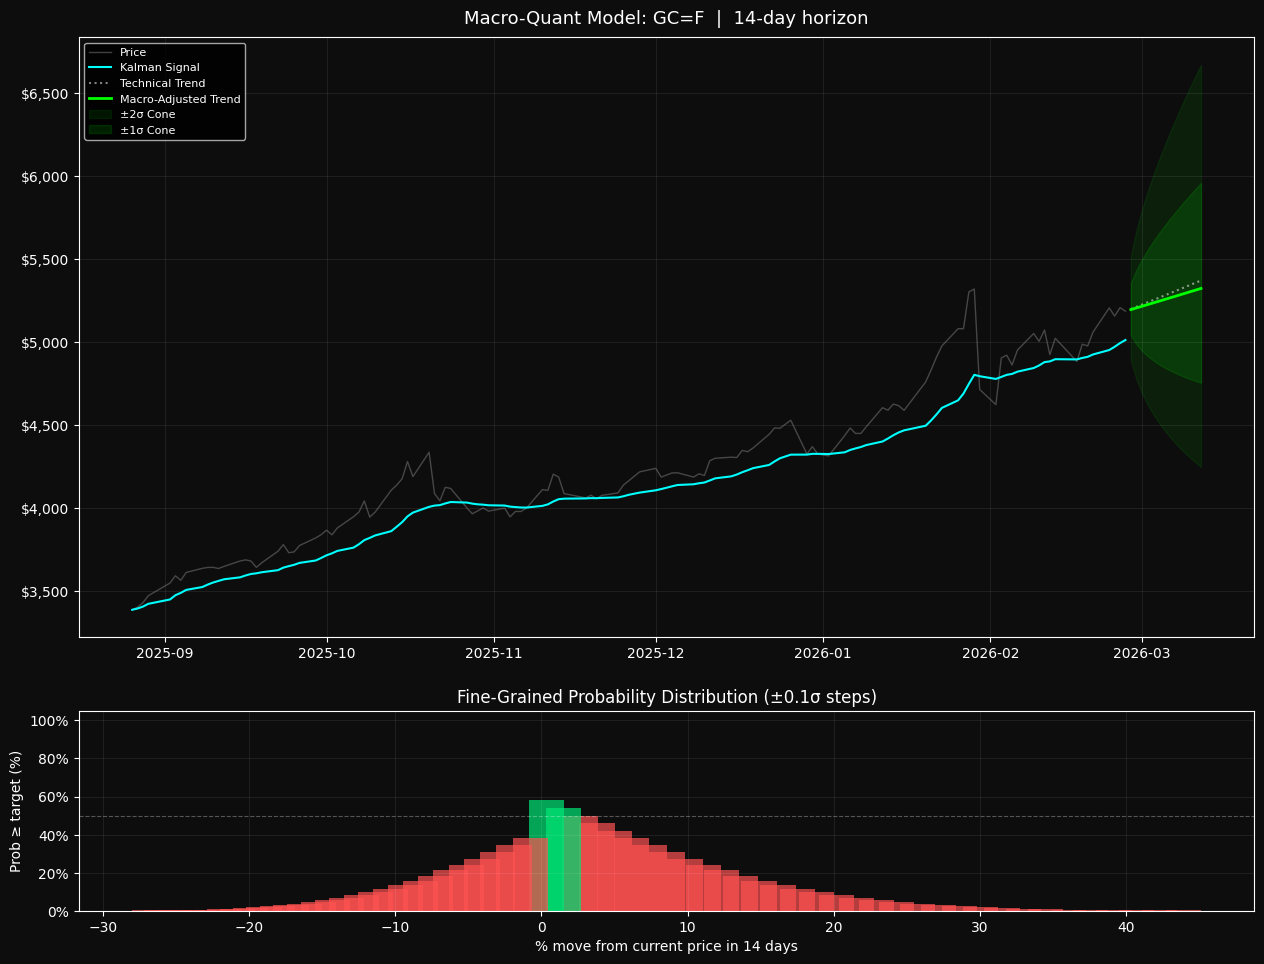

In [6]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import norm

# --- 1. CONFIGURATION ---
TARGET_ASSET = "GC=F"
MACRO_TICKERS = ["DX-Y.NYB", "^TNX", "^GSPC"]

INTERVAL = "1d"
LOOKBACK = "6mo"
HORIZON_STEPS = 14

# Kalman Tunings
PROCESS_NOISE = 1e-3
MEASUREMENT_NOISE = 1e-1

# Distribution Resolution
SIGMA_STEP = 0.1          # Step size between sigma levels
SIGMA_RANGE = 3.0         # Show from -3σ to +3σ
PROB_DISPLAY_THRESHOLD = 0.5  # Only print rows with prob >= this %

# --- 2. DATA FETCHER & ALIGNMENT ---
print("--- FETCHING DATA ---")
tickers_to_fetch = [TARGET_ASSET] + MACRO_TICKERS
data = yf.download(tickers_to_fetch, period=LOOKBACK, interval=INTERVAL,
                   group_by='ticker', progress=False)

if data.empty:
    raise ValueError("No data found.")

def get_close(ticker):
    try:
        if isinstance(data.columns, pd.MultiIndex):
            return data[ticker]['Close']
        return data['Close']
    except KeyError:
        print(f"Warning: Could not find data for {ticker}")
        return None

df = pd.DataFrame()
df['Target'] = get_close(TARGET_ASSET)
for m in MACRO_TICKERS:
    s = get_close(m)
    if s is not None:
        df[m] = s

df = df.ffill().dropna()
prices = df['Target'].values
dates  = df.index

# --- 3. MACRO FACTOR CALCULATION ---
returns      = np.log(df / df.shift(1)).dropna()
correlations = returns.corr()['Target']

rolling_mean = df.rolling(window=20).mean()
rolling_std  = df.rolling(window=20).std()
z_scores     = (df - rolling_mean) / rolling_std
current_z    = z_scores.iloc[-1]

macro_drag_score = 0.0
print(f"\n--- MACRO IMPACT ANALYSIS ---")
print(f"{'Asset':<12} | {'Corr':>6} | {'Z-Score':>8} | {'Impact':>8}")
print("-" * 46)

for m in MACRO_TICKERS:
    if m in df.columns:
        corr   = correlations[m]
        z      = current_z[m]
        impact = corr * z
        macro_drag_score += impact * 0.2
        print(f"{m:<12} | {corr:>+6.2f} | {z:>+8.2f} | {impact:>+8.2f}")

print("-" * 46)
print(f"TOTAL MACRO ADJUSTMENT: {macro_drag_score:+.4f} (Added to Drift)")

# --- 4. KALMAN FILTER ---
class KalmanFilter1D:
    def __init__(self, R, Q, initial_value):
        self.R = R; self.Q = Q; self.P = 1.0; self.x = initial_value

    def update(self, measurement):
        self.P   = self.P + self.Q
        K        = self.P / (self.P + self.R)
        self.x   = self.x + K * (measurement - self.x)
        self.P   = (1 - K) * self.P
        return self.x

kf = KalmanFilter1D(MEASUREMENT_NOISE, PROCESS_NOISE, prices[0])
kalman_signal = np.array([kf.update(p) for p in prices])

# --- 5. PROJECTION (WITH MACRO ADJUSTMENT) ---
current_price  = prices[-1]
trend_window   = 14
slope          = np.polyfit(np.arange(trend_window), kalman_signal[-trend_window:], 1)[0]
base_drift_pct = slope / current_price

adjusted_drift_pct = base_drift_pct + (macro_drag_score / 100)

step_volatility = np.std(np.diff(np.log(prices))[-30:])

future_steps = np.arange(1, HORIZON_STEPS + 1)
future_dates = pd.date_range(start=dates[-1], periods=HORIZON_STEPS + 1, freq='D')[1:]

path_tech  = current_price * np.exp(base_drift_pct  * future_steps)
path_macro = current_price * np.exp(adjusted_drift_pct * future_steps)

sigma_t    = step_volatility * np.sqrt(future_steps)
upper_cone = path_macro * np.exp(2 * sigma_t)
lower_cone = path_macro * np.exp(-2 * sigma_t)

# --- 6. FINE-GRAINED DISTRIBUTION (±0.1σ steps) ---
mu_total    = adjusted_drift_pct * HORIZON_STEPS   # total log-drift over horizon
sigma_total = step_volatility * np.sqrt(HORIZON_STEPS)
final_sigma = sigma_t[-1]
final_price = path_macro[-1]

# Build sigma grid
sigma_levels = np.round(
    np.arange(-SIGMA_RANGE, SIGMA_RANGE + SIGMA_STEP / 2, SIGMA_STEP), 1
)

print(f"\n--- FINE-GRAINED DISTRIBUTION  (horizon = {HORIZON_STEPS}d) ---")
print(f"Drift (technical): {base_drift_pct*100:+.4f}%/day  |  "
      f"Macro adj: {macro_drag_score:+.4f}  |  "
      f"σ/day: {step_volatility*100:.4f}%")
print(f"\n{'σ Level':>8}  {'Price':>12}  {'% from Now':>11}  {'Prob ≥ Target':>14}  {'Bar'}")
print("-" * 72)

bar_max   = 40   # characters for 100%
rows      = []

for sig in sigma_levels[::-1]:           # print from +3σ down to -3σ
    target   = final_price * np.exp(sig * final_sigma)
    pct_move = (target / current_price - 1) * 100
    z_score  = (np.log(target / current_price) - mu_total) / sigma_total

    if target > current_price:
        prob = (1 - norm.cdf(z_score)) * 100
    else:
        prob = norm.cdf(z_score) * 100

    rows.append((sig, target, pct_move, prob))

    if abs(prob - 50) > 49.5 * (1 - PROB_DISPLAY_THRESHOLD / 50):
        continue  # skip near-0% or near-100% edge rows

    bar    = "█" * int(prob / 100 * bar_max)
    marker = "  ◄ NOW" if abs(pct_move) < (SIGMA_STEP * final_sigma / current_price * 100 / 2) else ""
    print(f"{sig:>+7.1f}σ  ${target:>11,.0f}  {pct_move:>+10.2f}%  {prob:>13.1f}%  {bar}{marker}")

print("-" * 72)

# Highlight key quantiles
print(f"\n--- KEY QUANTILES ---")
for q_label, q_val in [("5th pct (strong bear)", 0.05),
                        ("25th pct (mild bear)",  0.25),
                        ("50th pct (median)",     0.50),
                        ("75th pct (mild bull)",  0.75),
                        ("95th pct (strong bull)",0.95)]:
    # Invert: find price where P(X <= price) = q_val
    log_ret   = norm.ppf(q_val) * sigma_total + mu_total
    q_price   = current_price * np.exp(log_ret)
    q_pct     = (q_price / current_price - 1) * 100
    print(f"  {q_label:<28}  ${q_price:>10,.0f}  ({q_pct:>+7.2f}%)")

# --- 7. VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10),
                                gridspec_kw={'height_ratios': [3, 1]})
plt.style.use('dark_background')
fig.patch.set_facecolor('#0d0d0d')

# ── Top panel: price + projections ──────────────────────────────────────────
ax1.set_facecolor('#0d0d0d')
ax1.plot(dates, prices, color='gray', alpha=0.5, label='Price', linewidth=1)
ax1.plot(dates, kalman_signal, color='cyan', label='Kalman Signal', linewidth=1.5)
ax1.plot(future_dates, path_tech, color='white', linestyle=':', alpha=0.5,
         label='Technical Trend')
ax1.plot(future_dates, path_macro, color='lime', linewidth=2,
         label='Macro-Adjusted Trend')
ax1.fill_between(future_dates, lower_cone, upper_cone,
                 color='lime', alpha=0.08, label='±2σ Cone')

# Add ±1σ inner cone
inner_upper = path_macro * np.exp(1 * sigma_t)
inner_lower = path_macro * np.exp(-1 * sigma_t)
ax1.fill_between(future_dates, inner_lower, inner_upper,
                 color='lime', alpha=0.12, label='±1σ Cone')

ax1.set_title(f"Macro-Quant Model: {TARGET_ASSET}  |  {HORIZON_STEPS}-day horizon",
              fontsize=13, color='white', pad=10)
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(True, alpha=0.08)
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# ── Bottom panel: probability bar chart at each ±0.1σ level ─────────────────
ax2.set_facecolor('#0d0d0d')
rows_arr  = np.array(rows)                  # (sig, price, pct, prob)
sigs      = rows_arr[:, 0]
probs     = rows_arr[:, 3]
pcts      = rows_arr[:, 2]

colors    = ['#00e676' if p >= 50 else '#ff5252' for p in probs]
ax2.bar(pcts, probs, width=step_volatility * 100 * 0.8,
        color=colors, alpha=0.7, edgecolor='none')
ax2.axhline(50, color='white', linestyle='--', alpha=0.3, linewidth=0.8)
ax2.set_xlabel(f"% move from current price in {HORIZON_STEPS} days", color='white')
ax2.set_ylabel("Prob ≥ target (%)", color='white')
ax2.set_title("Fine-Grained Probability Distribution (±0.1σ steps)", color='white')
ax2.grid(True, alpha=0.08)
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout(pad=2.0)

